# EdinburghAI: TinyML E-Nose

# Setup python environment

In [42]:
# Setup environment
%pip install pandas numpy matplotlib ai-edge-litert tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Constants

In [43]:
FEATURE_COLS = ["temperature", "pressure", "humidity", "gas_resistance"]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "label"

FILES = [
    "air",
    "basil",
    "cinnamon",
    "oregano",
    "rosemary"
]

# Load Data

In [44]:
import pandas as pd
import os

dfs = []

for folder in os.listdir("../data/dataset"):
    if '.' in folder: continue


    for file in os.listdir(f"../data/dataset/{folder}"):
        if not file.endswith(".csv"): continue

        df = pd.read_csv(f"../data/dataset/{folder}/{file}")
        dfs.append(df)


NUM_CLASSES = len(dfs)

data = pd.concat(dfs)
print(len(data), "entries")
data.head()

105717 entries


,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label
0,1,0,1,100,150,24.39,1022.75,46.61,414156,air
1,2,0,1,100,150,23.64,1099.59,58.00,135953,air
2,4,0,1,100,150,22.51,1096.55,56.40,107383,air
3,6,0,1,100,150,23.18,1102.17,57.21,159750,air
4,7,0,1,100,150,23.72,1056.94,53.37,237642,air


# Graph Data

In [45]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,6))

# datas = data.sample(n=1000)  # sample so it doesn't take 10 years
# sns.pairplot(datas[FEATURE_COLS+[TARGET_COL]], hue=TARGET_COL, palette='Set1', diag_kind='hist')
# plt.show()


# Train Neural Network

## Split data into training and testing

In [46]:
TESTING_RATIO = 0.1

training_data = data.sample(frac=(1-TESTING_RATIO), random_state=67)
data = data.reset_index(drop=True)
testing_data = data.drop(training_data.index)

print(f"{len(training_data)} training : {len(testing_data)} testing samples")

95145 training : 94741 testing samples


## Data Preprocessing

In [47]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

x_train = training_data[FEATURE_COLS]
y_train = training_data[TARGET_COL]

x_test = testing_data[FEATURE_COLS]
y_test = testing_data[TARGET_COL]


label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# x_train[:, 3] = np.log1p(x_train[:, 3])
# x_test[:, 3] = np.log1p(x_test[:, 3])

## Build model

In [48]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Input

model = Sequential()

model.add(Input(shape=(4,)))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,546 (6.04 KB)

 Trainable params: 1,546 (6.04 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [49]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train_enc,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3238 - loss: 1.5061 - val_accuracy: 0.4114 - val_loss: 1.3382
Epoch 2/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - accuracy: 0.3862 - loss: 1.3592 - val_accuracy: 0.4298 - val_loss: 1.2788
Epoch 3/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4043 - loss: 1.3131 - val_accuracy: 0.4431 - val_loss: 1.2412
Epoch 4/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.4156 - loss: 1.2838 - val_accuracy: 0.4603 - val_loss: 1.2063
Epoch 5/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - accuracy: 0.4290 - loss: 1.2567 - val_accuracy: 0.4815 - val_loss: 1.1691
Epoch 6/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - accuracy: 0.4456 - loss: 1.2217 - val_accuracy: 0.5047 - val_loss: 1.1238
Epoch 7/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4645 - loss: 1.1881 - val_accuracy: 0.5278 - val_loss: 1.0778
Epoch 8/200
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4735 -

## Graph the loss

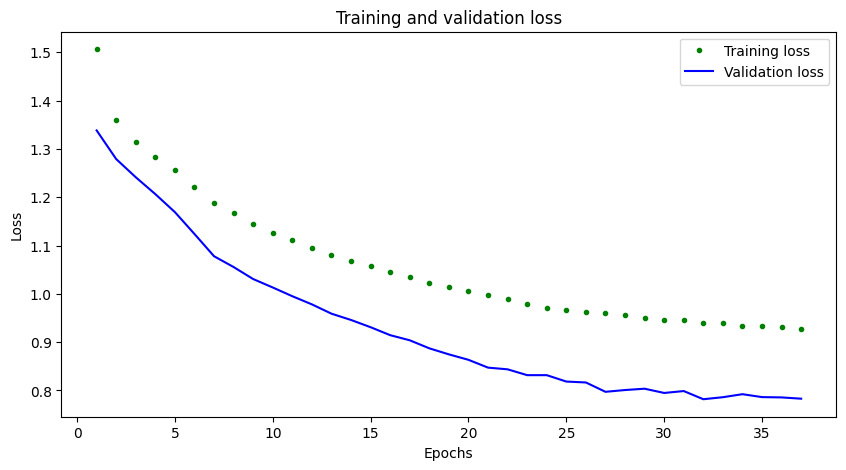

[10.0, 5.0]


In [50]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

# Run with test data

In [51]:
test_loss, test_acc = model.evaluate(x_test, y_test_enc)
print("Test accuracy:", test_acc)

2961/2961 ━━━━━━━━━━━━━━━━━━━━ 2s 727us/step - accuracy: 0.7082 - loss: 0.7588
Test accuracy: 0.708204448223114


In [52]:
from collections import defaultdict

# Track correct + total per class
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Use the Keras model (faster than LiteRT for evaluation)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

for true, pred in zip(y_test_enc, y_pred):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

# Print per-class accuracy
print("\nPer-class accuracy:")
for class_idx in sorted(class_total.keys()):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    acc = class_correct[class_idx] / class_total[class_idx]
    print(f"{class_name:20s} | {acc:.4f} ({class_correct[class_idx]}/{class_total[class_idx]})")

2961/2961 ━━━━━━━━━━━━━━━━━━━━ 2s 556us/step

Per-class accuracy:
air                  | 0.8865 (9122/10290)
basil                | 0.3592 (7556/21035)
cinnamon             | 0.7631 (16105/21106)
oregano              | 0.7326 (15679/21403)
rosemary             | 0.8913 (18634/20907)


# Confusion Matrix

2961/2961 ━━━━━━━━━━━━━━━━━━━━ 2s 539us/step


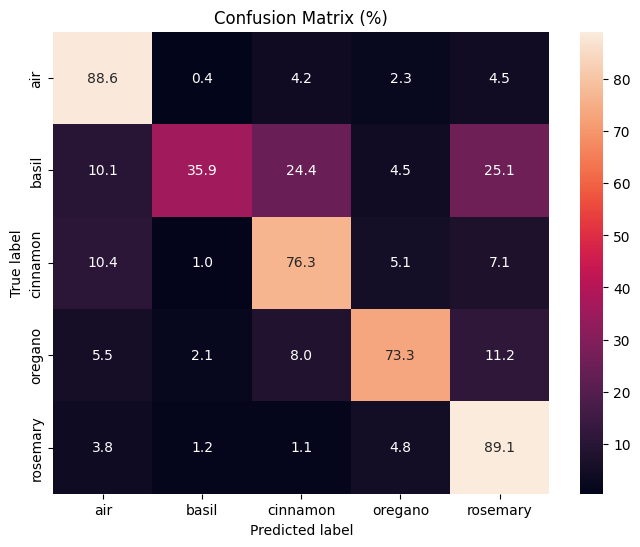

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix (counts)
cm = confusion_matrix(y_test_enc, y_pred)

# Convert to percentages (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

# Handle any divide-by-zero (just in case)
cm_percent = np.nan_to_num(cm_percent)

# Class labels
class_names = label_encoder.classes_

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (%)")
plt.show()

# Convert to litert model

In [54]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantization
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)

INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpnddogkof\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpnddogkof\assets


Saved artifact at 'C:\Users\james\AppData\Local\Temp\tmpnddogkof'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2203515607504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2203515611920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2203515611536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2203515607696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2204941210576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2203515612880: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 5664 bytes


## Test litert model

In [55]:
from ai_edge_litert.compiled_model import CompiledModel

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)


n_correct = 0

for i in range(len(x_test)):
    input_data = np.float32(x_test[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_enc[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(x_test))

LiteRT accuracy: 0.7159730211840702


## Encode the model in an arduino header file

In [56]:
with open("model.tflite", "rb") as f:
    data = f.read()

with open("model.h", "w") as f:
    f.write("const unsigned char model[] = {\n")
    
    for i, byte in enumerate(data):
        f.write(f"0x{byte:02x},")
        if (i + 1) % 12 == 0:
            f.write("\n")
    
    f.write("\n};\n")
    f.write(f"const unsigned int model_len = {len(data)};\n")

import os
print(f"Header file, model.h, is {os.path.getsize('model.h'):,} bytes.")

Header file, model.h, is 29,341 bytes.
